# Intel Image Classification — ML Pipeline
**African Leadership University — Machine Learning Pipeline Summative**

This notebook covers:
1. Data Acquisition
2. Data Preprocessing
3. Model Creation (Transfer Learning CNN)
4. Model Testing / Evaluation
5. Model Retraining Function + Trigger Logic
6. Saving artifacts for deployment

In [2]:
!pip install -q kaggle

import os


KAGGLE_API_TOKEN = "KGAT_fb64c03fd0cd05179ca4b7254eda5362"

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_API_TOKEN)

!chmod 600 /root/.kaggle/access_token

!kaggle datasets download -d puneet6060/intel-image-classification -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:06<00:00, 54.0MB/s]



## 1. Data Acquisition
The dataset contains `seg_train`, `seg_test`, and `seg_pred` folders, each with
6 classes: `buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`.

In [3]:
import os

base_path = "/content/data"
for root, dirs, files_ in os.walk(base_path):
    if root.count(os.sep) - base_path.count(os.sep) <= 2:
        print(root, "->", len(files_), "files")

/content/data -> 0 files
/content/data/seg_test -> 0 files
/content/data/seg_test/seg_test -> 0 files
/content/data/seg_train -> 0 files
/content/data/seg_train/seg_train -> 0 files
/content/data/seg_pred -> 0 files
/content/data/seg_pred/seg_pred -> 7301 files


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score, f1_score)

train_dir = "/content/data/seg_train/seg_train"
test_dir  = "/content/data/seg_test/seg_test"

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
CLASSES = sorted(os.listdir(train_dir))
print("Classes:", CLASSES)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 2. Data Visualizations & Insights
Before preprocessing, let's understand class balance, sample images, and
pixel intensity patterns — this feeds the "Data Insights" rubric requirement.

/tmp/ipykernel_3329/4218465369.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")


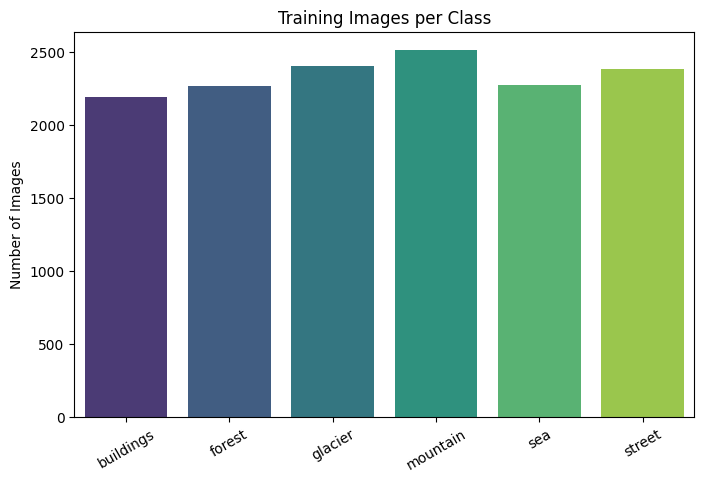

{'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}


In [5]:
counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in CLASSES}

plt.figure(figsize=(8,5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
plt.title("Training Images per Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

print(counts)

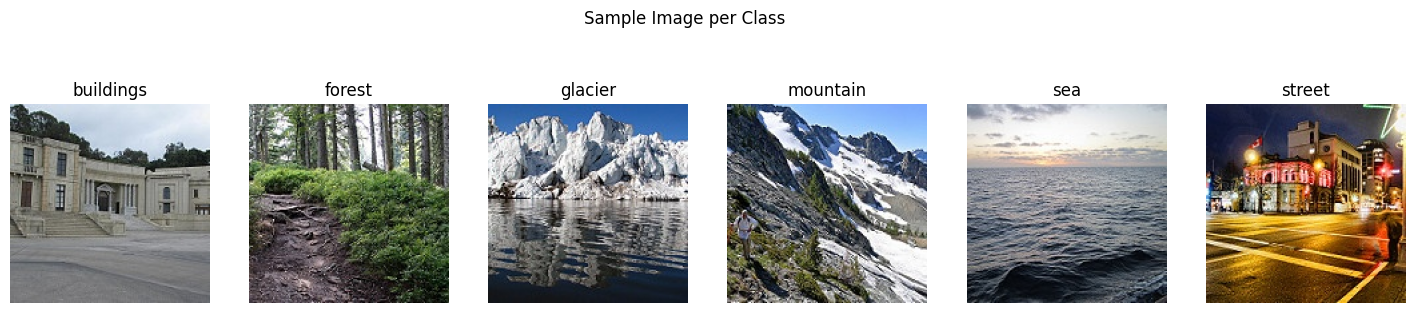

In [6]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(18,4))
for ax, cls in zip(axes, CLASSES):
    folder = os.path.join(train_dir, cls)
    img_name = os.listdir(folder)[0]
    img = plt.imread(os.path.join(folder, img_name))
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.suptitle("Sample Image per Class")
plt.show()

/tmp/ipykernel_3329/4251733907.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(brightness.keys()), y=list(brightness.values()), palette="mako")


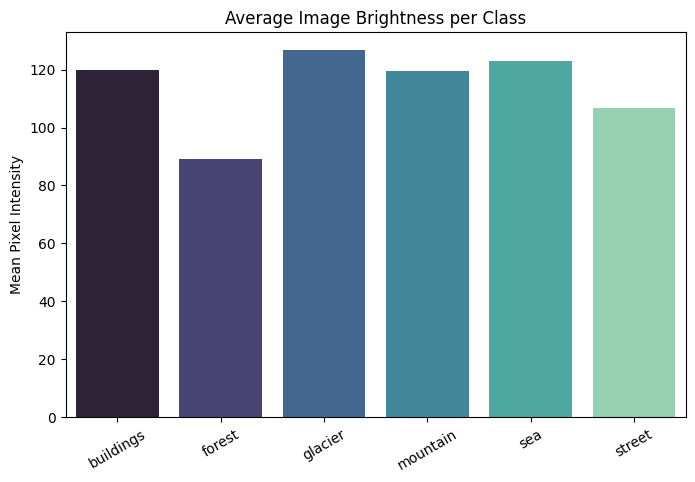

In [7]:
import cv2

def avg_brightness(cls, n=100):
    folder = os.path.join(train_dir, cls)
    files_ = os.listdir(folder)[:n]
    vals = []
    for f in files_:
        img = cv2.imread(os.path.join(folder, f))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        vals.append(gray.mean())
    return np.mean(vals)

brightness = {c: avg_brightness(c) for c in CLASSES}

plt.figure(figsize=(8,5))
sns.barplot(x=list(brightness.keys()), y=list(brightness.values()), palette="mako")
plt.title("Average Image Brightness per Class")
plt.ylabel("Mean Pixel Intensity")
plt.xticks(rotation=30)
plt.show()

## 3. Data Preprocessing
Using `ImageDataGenerator` for rescaling, augmentation, and train/validation split.

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)

val_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print(train_generator.class_indices)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


## 4. Model Creation
Transfer learning with MobileNetV2 (frozen base) + custom classification head.
Optimization techniques used: pretrained base, Dropout regularization,
Early Stopping, and ReduceLROnPlateau.

In [9]:
base_model = MobileNetV2(input_shape=(150,150,3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze pretrained base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(len(CLASSES), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/tmp/ipykernel_3329/2467883994.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150,150,3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
os.makedirs('/content/models', exist_ok=True)

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint('/content/models/intel_cnn_model.h5',
                              monitor='val_accuracy', save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)

callbacks = [early_stop, checkpoint, reduce_lr]

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.7194 - loss: 0.7433

351/351 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.7956 - loss: 0.5461 - val_accuracy: 0.8680 - val_loss: 0.3681 - learning_rate: 0.0010
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 341s 971ms/step - accuracy: 0.8504 - loss: 0.4010 - val_accuracy: 0.8584 - val_loss: 0.3798 - learning_rate: 0.0010
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 850ms/step - accuracy: 0.8597 - loss: 0.3892

351/351 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.8634 - loss: 0.3764 - val_accuracy: 0.8766 - val_loss: 0.3346 - learning_rate: 0.0010
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.8753 - loss: 0.3408

351/351 ━━━━━━━━━━━━━━━━━━━━ 350s 997ms/step - accuracy: 0.8733 - loss: 0.3464 - val_accuracy: 0.8855 - val_loss: 0.3271 - learning_rate: 0.0010
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 360s 1s/step - accuracy: 0.8699 - loss: 0.3531 - val_accuracy: 0.8727 - val_loss: 0.3436 - learning_rate: 0.0010
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.8725 - loss: 0.3351 - val_accuracy: 0.8784 - val_loss: 0.3323 - learning_rate: 0.0010
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.8868 - loss: 0.3094

351/351 ━━━━━━━━━━━━━━━━━━━━ 342s 976ms/step - accuracy: 0.8829 - loss: 0.3121 - val_accuracy: 0.8902 - val_loss: 0.2947 - learning_rate: 3.0000e-04
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8968 - loss: 0.2837

351/351 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.8921 - loss: 0.2929 - val_accuracy: 0.8916 - val_loss: 0.3125 - learning_rate: 3.0000e-04
Epoch 9/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.8924 - loss: 0.2969 - val_accuracy: 0.8869 - val_loss: 0.3082 - learning_rate: 3.0000e-04
Epoch 10/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.9008 - loss: 0.2809 - val_accuracy: 0.8905 - val_loss: 0.2980 - learning_rate: 9.0000e-05
Epoch 11/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.8995 - loss: 0.2768

351/351 ━━━━━━━━━━━━━━━━━━━━ 344s 980ms/step - accuracy: 0.9019 - loss: 0.2782 - val_accuracy: 0.8934 - val_loss: 0.2996 - learning_rate: 9.0000e-05


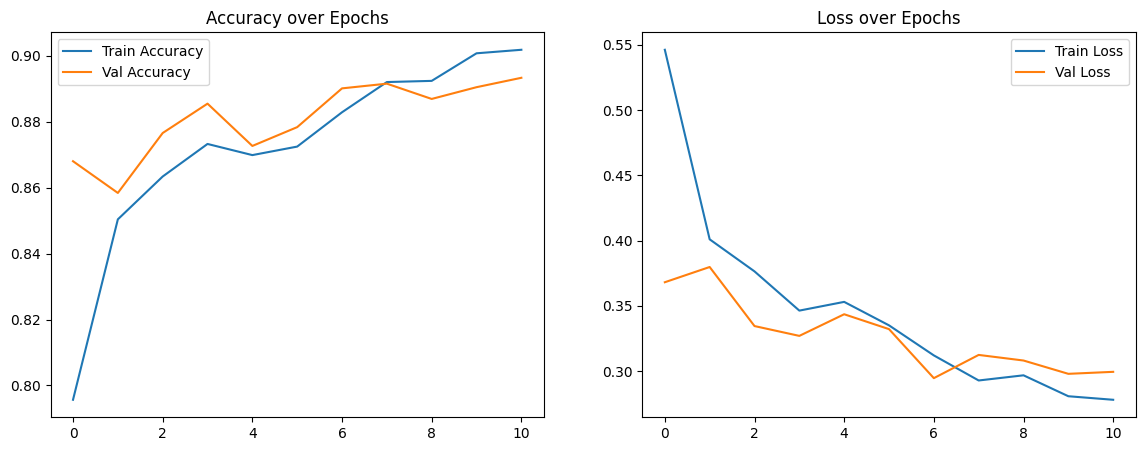

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()

plt.show()

## 5. Model Testing / Evaluation
Using the held-out `seg_test` set with 4+ metrics: Accuracy, Precision,
Recall, F1-score, plus loss and a confusion matrix.

In [13]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nFull classification report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

94/94 ━━━━━━━━━━━━━━━━━━━━ 57s 603ms/step - accuracy: 0.9020 - loss: 0.2635
Test Loss: 0.2635 | Test Accuracy: 0.9020
94/94 ━━━━━━━━━━━━━━━━━━━━ 59s 607ms/step
Precision: 0.9034
Recall: 0.9020
F1-score: 0.9018

Full classification report:
              precision    recall  f1-score   support

   buildings       0.92      0.92      0.92       437
      forest       0.98      0.99      0.98       474
     glacier       0.88      0.78      0.83       553
    mountain       0.80      0.88      0.84       525
         sea       0.95      0.93      0.94       510
      street       0.91      0.92      0.92       501

    accuracy                           0.90      3000
   macro avg       0.91      0.91      0.90      3000
weighted avg       0.90      0.90      0.90      3000



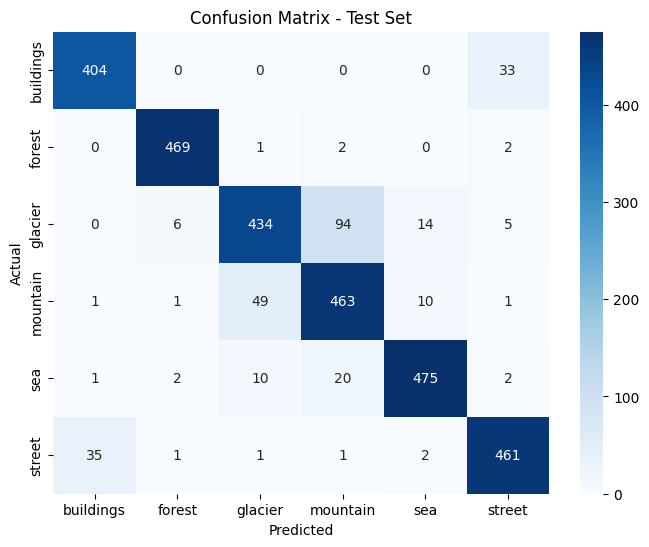

In [14]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

## 6. Save Final Model Artifact

In [15]:
model.save('/content/models/intel_cnn_model.h5')
print("Model saved.")

import json
with open('/content/models/class_indices.json', 'w') as f:
    json.dump(train_generator.class_indices, f)

Model saved.


## 7. Prediction Function (single image)

In [16]:
def predict_image(img_path, model_path='/content/models/intel_cnn_model.h5'):
    model = load_model(model_path)
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    class_idx = np.argmax(preds)
    confidence = float(np.max(preds))

    idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
    return idx_to_class[class_idx], confidence

# Example test
sample_path = os.path.join(test_dir, CLASSES[0], os.listdir(os.path.join(test_dir, CLASSES[0]))[0])
label, conf = predict_image(sample_path)
print(f"Predicted: {label} ({conf*100:.2f}% confidence)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: buildings (94.20% confidence)


## 8. Retraining Function + Trigger Logic
This function retrains the existing saved model (used as a pretrained base)
on newly uploaded data, satisfying the "uses the model created as a pretrained model" requirement.

In [17]:
def retrain_model(new_data_dir, model_path='/content/models/intel_cnn_model.h5',
                   epochs=5, min_new_images=20):
    """
    Retrains the existing model on new_data_dir (structured like train_dir:
    one subfolder per class). Triggers only if enough new data is present.
    """
    # Count new images to decide if retraining should trigger
    total_new = sum(len(os.listdir(os.path.join(new_data_dir, c)))
                     for c in os.listdir(new_data_dir)
                     if os.path.isdir(os.path.join(new_data_dir, c)))

    if total_new < min_new_images:
        print(f"Only {total_new} new images found. Minimum {min_new_images} required. Skipping retrain.")
        return None

    print(f"Trigger activated: {total_new} new images found. Starting retraining...")

    existing_model = load_model(model_path)

    new_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    new_train_gen = new_datagen.flow_from_directory(
        new_data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='training'
    )
    new_val_gen = new_datagen.flow_from_directory(
        new_data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='validation'
    )

    existing_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                            loss='categorical_crossentropy', metrics=['accuracy'])

    history_retrain = existing_model.fit(
        new_train_gen, validation_data=new_val_gen, epochs=epochs,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
    )

    existing_model.save(model_path)
    print("Retraining complete. Model updated at:", model_path)
    return history_retrain

In [18]:
from google.colab import files
files.download('/content/models/intel_cnn_model.h5')
files.download('/content/models/class_indices.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import shutil, os, random

def create_sample(src_dir, dest_dir, n_per_class=25):
    os.makedirs(dest_dir, exist_ok=True)
    classes = os.listdir(src_dir)
    for cls in classes:
        src_cls_dir = os.path.join(src_dir, cls)
        dest_cls_dir = os.path.join(dest_dir, cls)
        os.makedirs(dest_cls_dir, exist_ok=True)
        images = os.listdir(src_cls_dir)
        sample = random.sample(images, min(n_per_class, len(images)))
        for img in sample:
            shutil.copy(os.path.join(src_cls_dir, img), os.path.join(dest_cls_dir, img))
    print(f"Sampled {n_per_class} images per class into {dest_dir}")

# Sample from train and test
create_sample("/content/data/seg_train/seg_train", "/content/sample_data/train", n_per_class=25)
create_sample("/content/data/seg_test/seg_test", "/content/sample_data/test", n_per_class=10)

# Zip it up
shutil.make_archive("/content/sample_data_zip", 'zip', "/content/sample_data")

from google.colab import files
files.download("/content/sample_data_zip.zip")

Sampled 25 images per class into /content/sample_data/train
Sampled 10 images per class into /content/sample_data/test


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>